# UniTable Output Inspector

Run UniTable on a single image and analyze the raw output.

In [55]:
import os
import sys
import importlib.util
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML
from bs4 import BeautifulSoup

Image.MAX_IMAGE_PIXELS = None

project_root = Path.cwd().parent
huma_root    = project_root / "Huma-Huma"

for p in [project_root, huma_root, huma_root / "unitable", project_root / "pubtabnet" / "src"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from dotenv import load_dotenv
load_dotenv(dotenv_path=project_root / '.env', override=True)

from metric import TEDS
print('Imports OK')

Imports OK


In [56]:
# ── Load UniTable ─────────────────────────────────────────────────────────────
spec = importlib.util.spec_from_file_location(
    'unitable_extractor',
    str(huma_root / 'table_extraction' / 'unitable.py'),
)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
extractor = mod.UniTableExtractor()
print(f'UniTable ready — device: {extractor.device}')

Loading UniTable models...
  ✓ Structure model loaded
  ✓ Bbox model loaded
  ✓ Content model loaded
UniTable ready for inference!
UniTable ready — device: mps


In [ ]:
# ── Config: point at any image ────────────────────────────────────────────────
EVAL_DIR = project_root / 'eval_unitable_results'

all_images = sorted(EVAL_DIR.glob('*.png'))
print(f"Available: {len(all_images)} images")

# Set IMAGE_NAME to a specific file, or set to None to use INDEX
IMAGE_NAME = "imgid_698316_TEDS0.907.png"
INDEX      = 2

if IMAGE_NAME:
    IMAGE_PATH = EVAL_DIR / IMAGE_NAME
    print(f"\nSelected by name: {IMAGE_PATH.name}")
else:
    IMAGE_PATH = all_images[INDEX]
    print(f"\nSelected [{INDEX}]: {IMAGE_PATH.name}")

Available: 500 images

Selected by name: imgid_727595_TEDS0.805.png


Size: 486 × 399 px  |  Mode: RGB


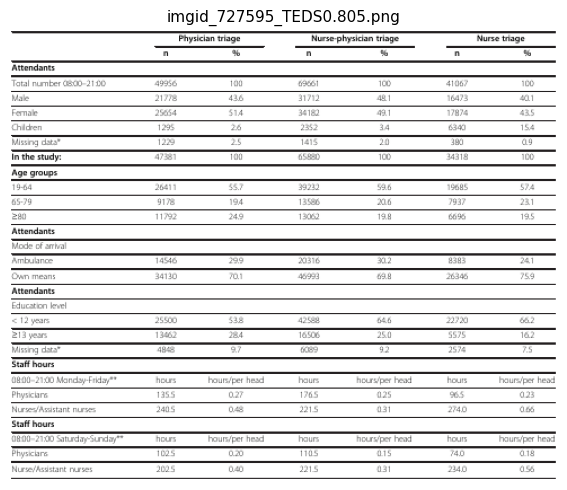

In [58]:
# ── Load and display input image ──────────────────────────────────────────────
img = Image.open(IMAGE_PATH)
print(f'Size: {img.size[0]} × {img.size[1]} px  |  Mode: {img.mode}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(img)
ax.set_title(IMAGE_PATH.name, fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

In [59]:
# ── Run UniTable ─────────────────────────────────────────────────────────────
import time
t0 = time.time()
raw_html, cell_bboxes, cell_texts, structure_tokens = extractor.extract_html_with_bboxes(img)
elapsed = time.time() - t0

print(f"Done in {elapsed:.1f}s")
print(f"HTML length:          {len(raw_html) if raw_html else 0} chars")
print(f"Cell bboxes detected: {len(cell_bboxes)}")
print(f"Cell texts:           {len(cell_texts)}")
print(f"Structure tokens:     {len(structure_tokens)}")


Done in 204.2s
HTML length:          3078 chars
Cell bboxes detected: 157
Cell texts:           157
Structure tokens:     280


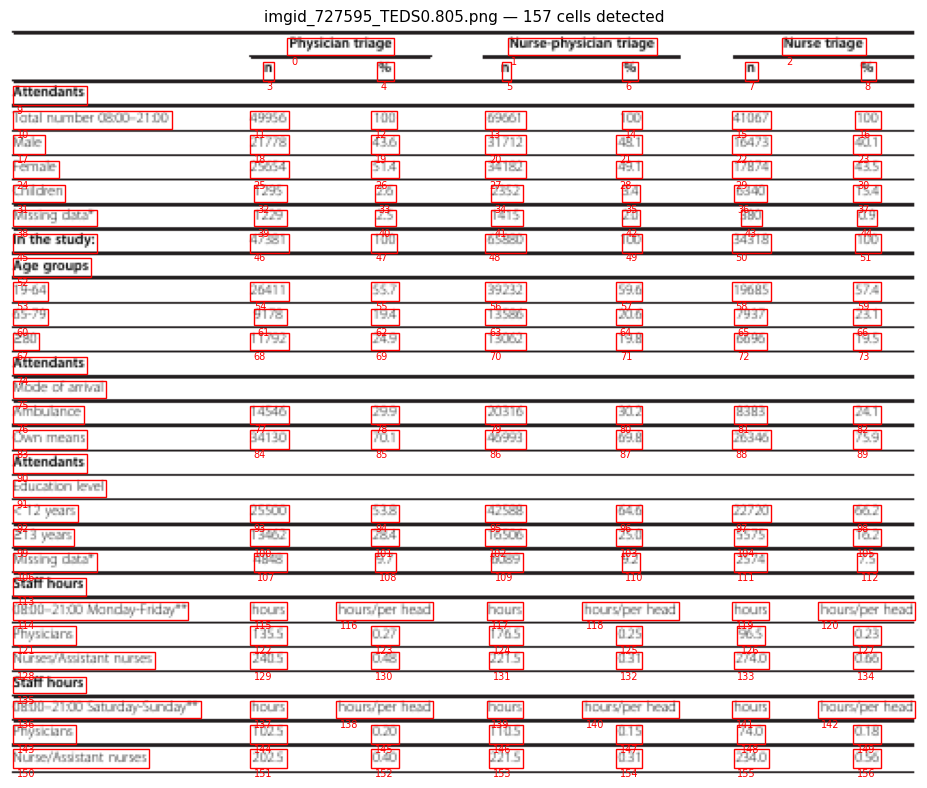

BBox list (x1, y1, x2, y2):
  [  0] [148, 4, 205, 13]
  [  1] [266, 4, 346, 13]
  [  2] [413, 4, 458, 13]
  [  3] [135, 17, 141, 27]
  [  4] [196, 17, 205, 27]
  [  5] [263, 17, 268, 27]
  [  6] [327, 17, 336, 27]
  [  7] [393, 17, 400, 27]
  [  8] [455, 17, 463, 27]
  [  9] [1, 30, 41, 40]
  [ 10] [1, 43, 86, 53]
  [ 11] [128, 43, 149, 53]
  [ 12] [193, 43, 207, 53]
  [ 13] [254, 43, 276, 53]
  [ 14] [327, 43, 338, 53]
  [ 15] [386, 43, 407, 53]
  [ 16] [452, 43, 466, 53]
  [ 17] [1, 56, 18, 66]
  [ 18] [128, 56, 149, 66]
  [ 19] [193, 56, 208, 66]
  [ 20] [254, 56, 276, 66]
  [ 21] [324, 56, 338, 66]
  [ 22] [386, 56, 407, 66]
  [ 23] [451, 56, 466, 66]
  [ 24] [1, 70, 26, 79]
  [ 25] [128, 70, 149, 79]
  [ 26] [193, 70, 208, 79]
  [ 27] [254, 70, 276, 79]
  [ 28] [324, 70, 338, 79]
  [ 29] [386, 70, 407, 79]
  [ 30] [451, 70, 466, 79]
  [ 31] [1, 83, 29, 92]
  [ 32] [130, 83, 148, 92]
  [ 33] [195, 83, 206, 92]
  [ 34] [257, 83, 274, 92]
  [ 35] [327, 83, 337, 92]
  [ 36] [387, 83, 

In [60]:
# ── Overlay cell bboxes on image ──────────────────────────────────────────────
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img)
ax.set_title(f"{IMAGE_PATH.name} — {len(cell_bboxes)} cells detected", fontsize=11)
ax.axis("off")

for i, (x1, y1, x2, y2) in enumerate(cell_bboxes):
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=1, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1 + 2, y1 + 10, str(i), color="red", fontsize=7, va="top")

plt.tight_layout()
plt.show()

print("BBox list (x1, y1, x2, y2):")
for i, b in enumerate(cell_bboxes):
    print(f"  [{i:3d}] {b}")


In [61]:
# ── Cell values table (index, bbox, text) ────────────────────────────────────
rows = []
for i, (bbox, text) in enumerate(zip(cell_bboxes, cell_texts)):
    x1, y1, x2, y2 = bbox
    rows.append({
        "idx":  i,
        "x1": x1, "y1": y1, "x2": x2, "y2": y2,
        "w": x2 - x1, "h": y2 - y1,
        "text": text,
    })

df_cells = pd.DataFrame(rows)
print(f"{len(df_cells)} cells")
display(df_cells)


157 cells


,idx,x1,y1,x2,y2,w,h,text
0,0,148,4,205,13,57,9,Physician triage
1,1,266,4,346,13,80,9,Nurse - physician triage
2,2,413,4,458,13,45,9,Nurse triage
3,3,135,17,141,27,6,10,n
4,4,196,17,205,27,9,10,%
...,...,...,...,...,...,...,...,...
152,152,193,385,208,395,15,10,0.40
153,153,256,385,274,395,18,10,221.5
154,154,324,385,338,395,14,10,0.31
155,155,387,385,406,395,19,10,234.0


In [62]:
# ── Raw HTML output ───────────────────────────────────────────────────────────
print('=== RAW HTML (full) ===')
print(raw_html)

=== RAW HTML (full) ===
<html>
        <head> <meta charset="UTF-8">
        <style>
        table, th, td {
            border: 1px solid black;
            font-size: 10px;
        }
        </style> </head>
        <body>
        <table frame="hsides" rules="groups" width="100%%">
            <thead><tr><td>Physician triage</td><td  colspan="2">Nurse - physician triage</td><td  colspan="2">Nurse triage</td><td  colspan="2">n</td></tr><tr><td>%</td><td>n</td><td>%</td><td>n</td><td>%</td><td>Attendants</td><td>Total number 08 : 00 – 21 : 00</td></tr></thead><tbody><tr><td>49956</td><td>100</td><td>69661</td><td>100</td><td>41067</td><td>100</td><td>Male</td></tr><tr><td>21778</td><td>43.6</td><td>31712</td><td>48.1</td><td>16473</td><td>40.1</td><td>Female</td></tr><tr><td>25654</td><td>51.4</td><td>34182</td><td>49.1</td><td>17874</td><td>43.5</td><td>Children</td></tr><tr><td>1295</td><td>2.6</td><td>2352</td><td>3.4</td><td>6340</td><td>15.4</td><td>Missing data *</td></tr><tr><td

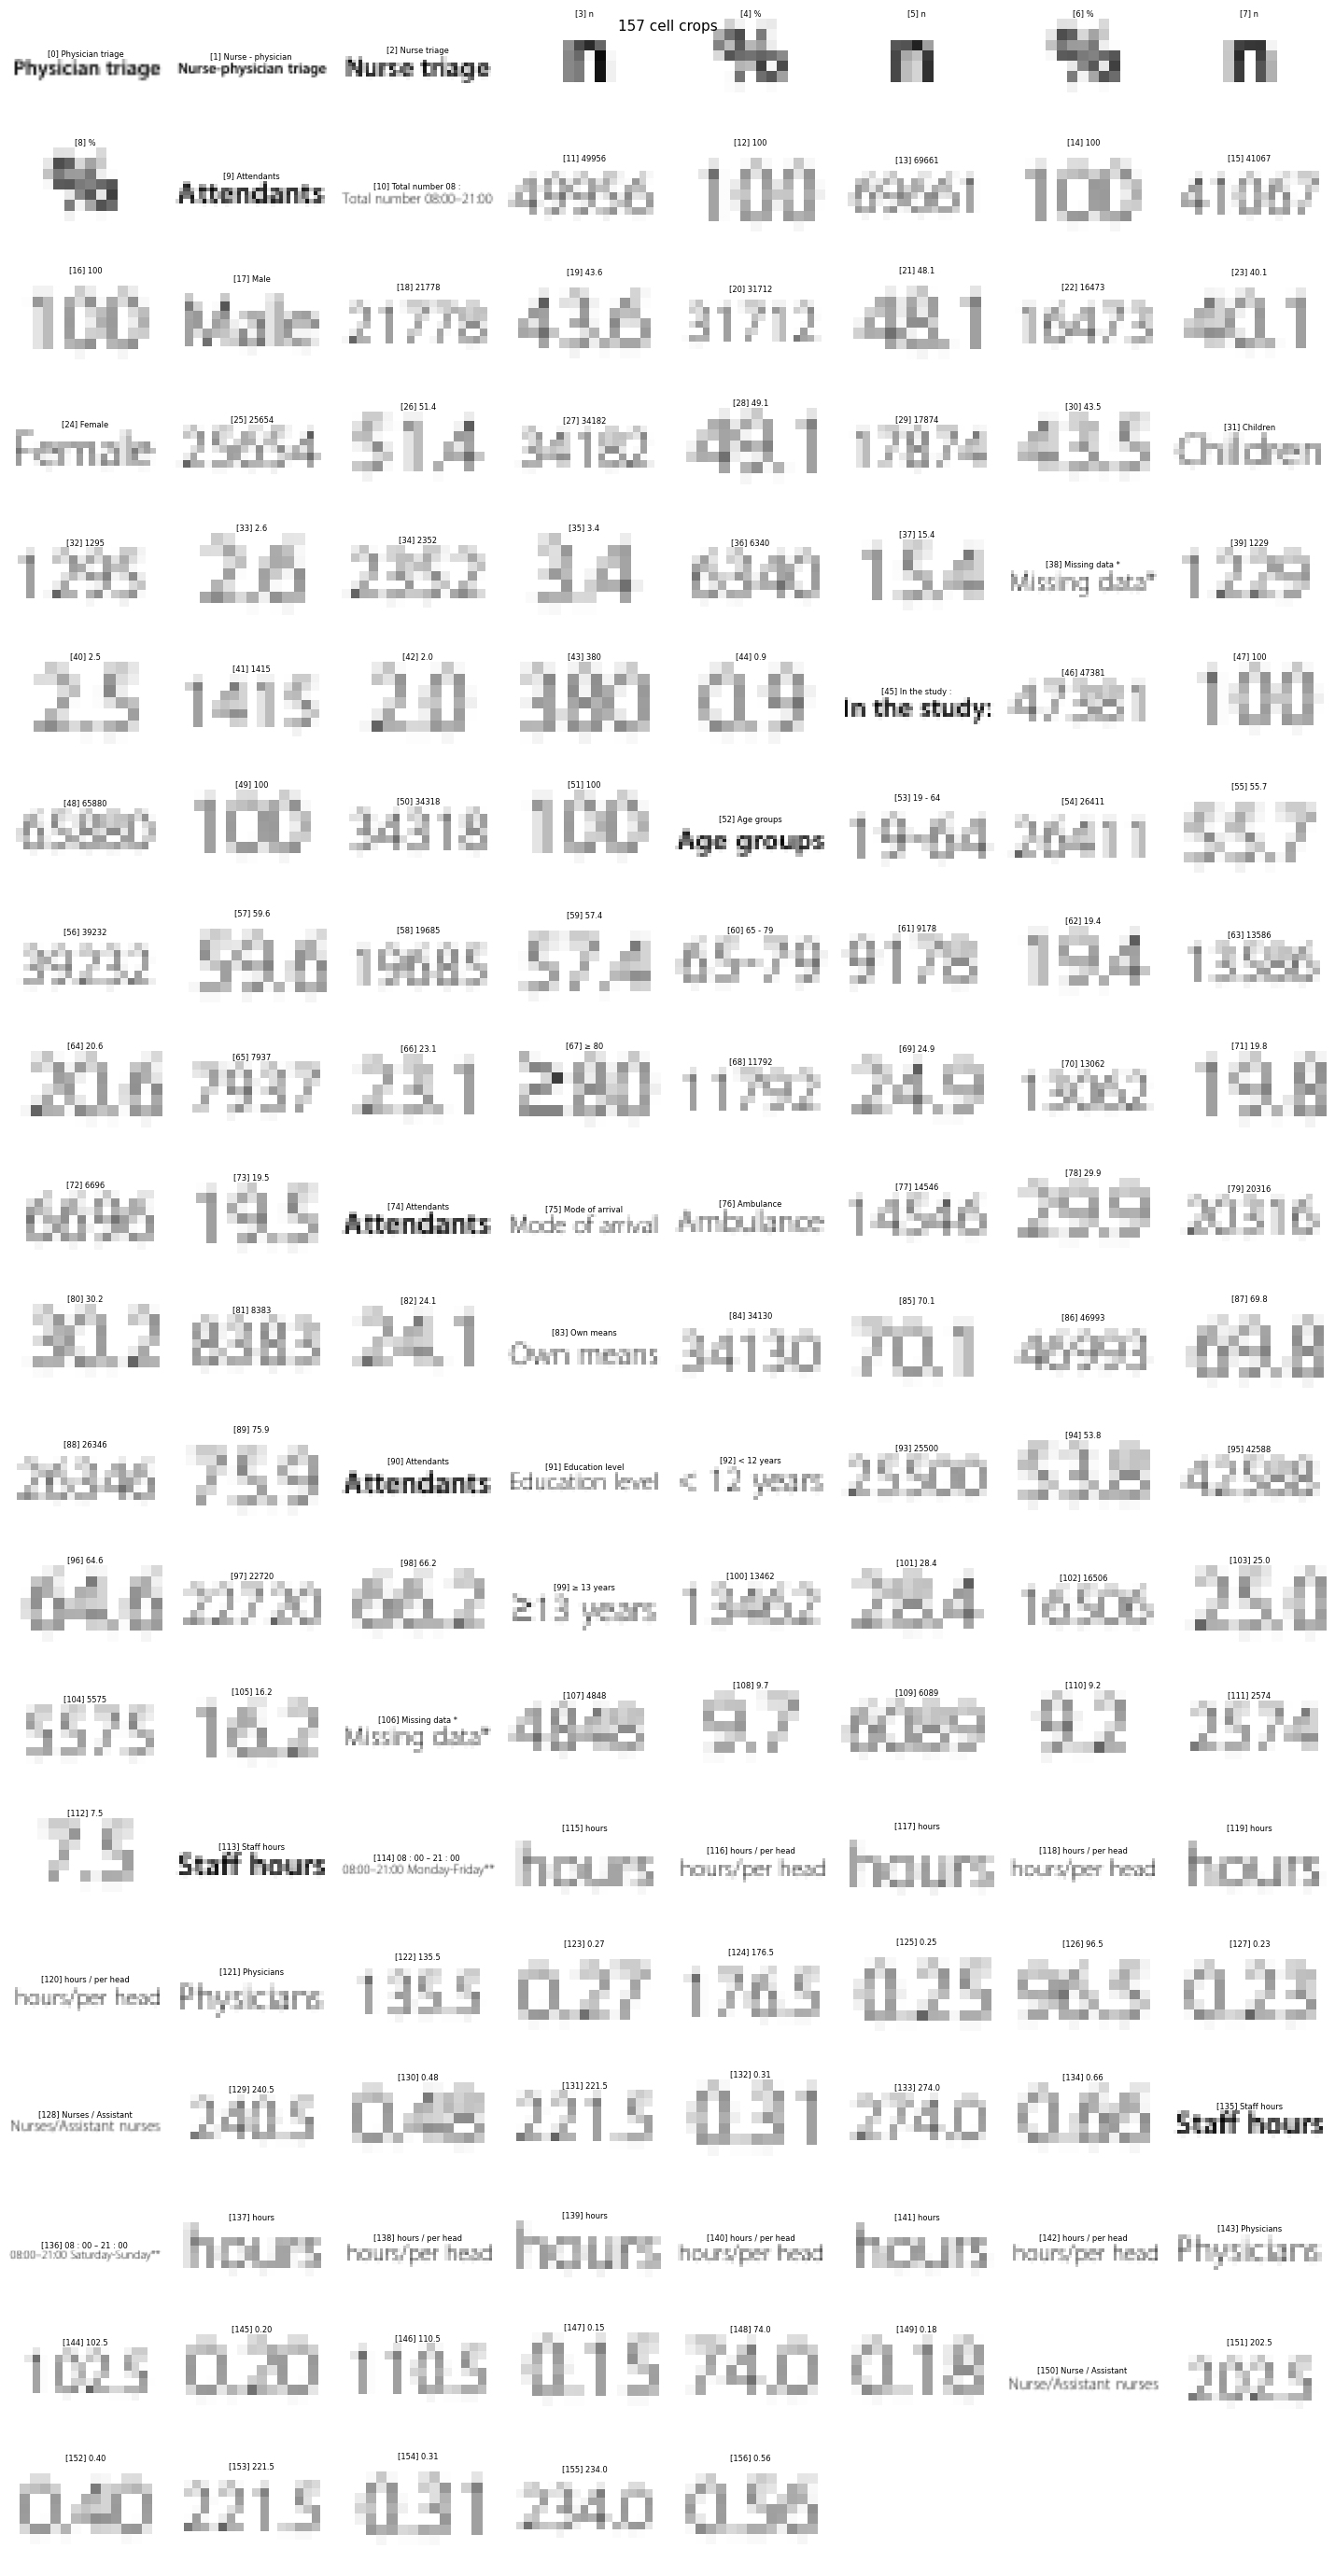

In [63]:
# ── Visualize all cell crops ──────────────────────────────────────────────────
n = len(cell_bboxes)
cols = 8
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.4))
axes = axes.flatten()

for i, (bbox, text) in enumerate(zip(cell_bboxes, cell_texts)):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    crop = img.crop((x1, y1, x2, y2))
    axes[i].imshow(crop)
    axes[i].set_title(f"[{i}] {text[:18]}", fontsize=6, pad=2)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"{n} cell crops", fontsize=11)
plt.tight_layout()
plt.show()


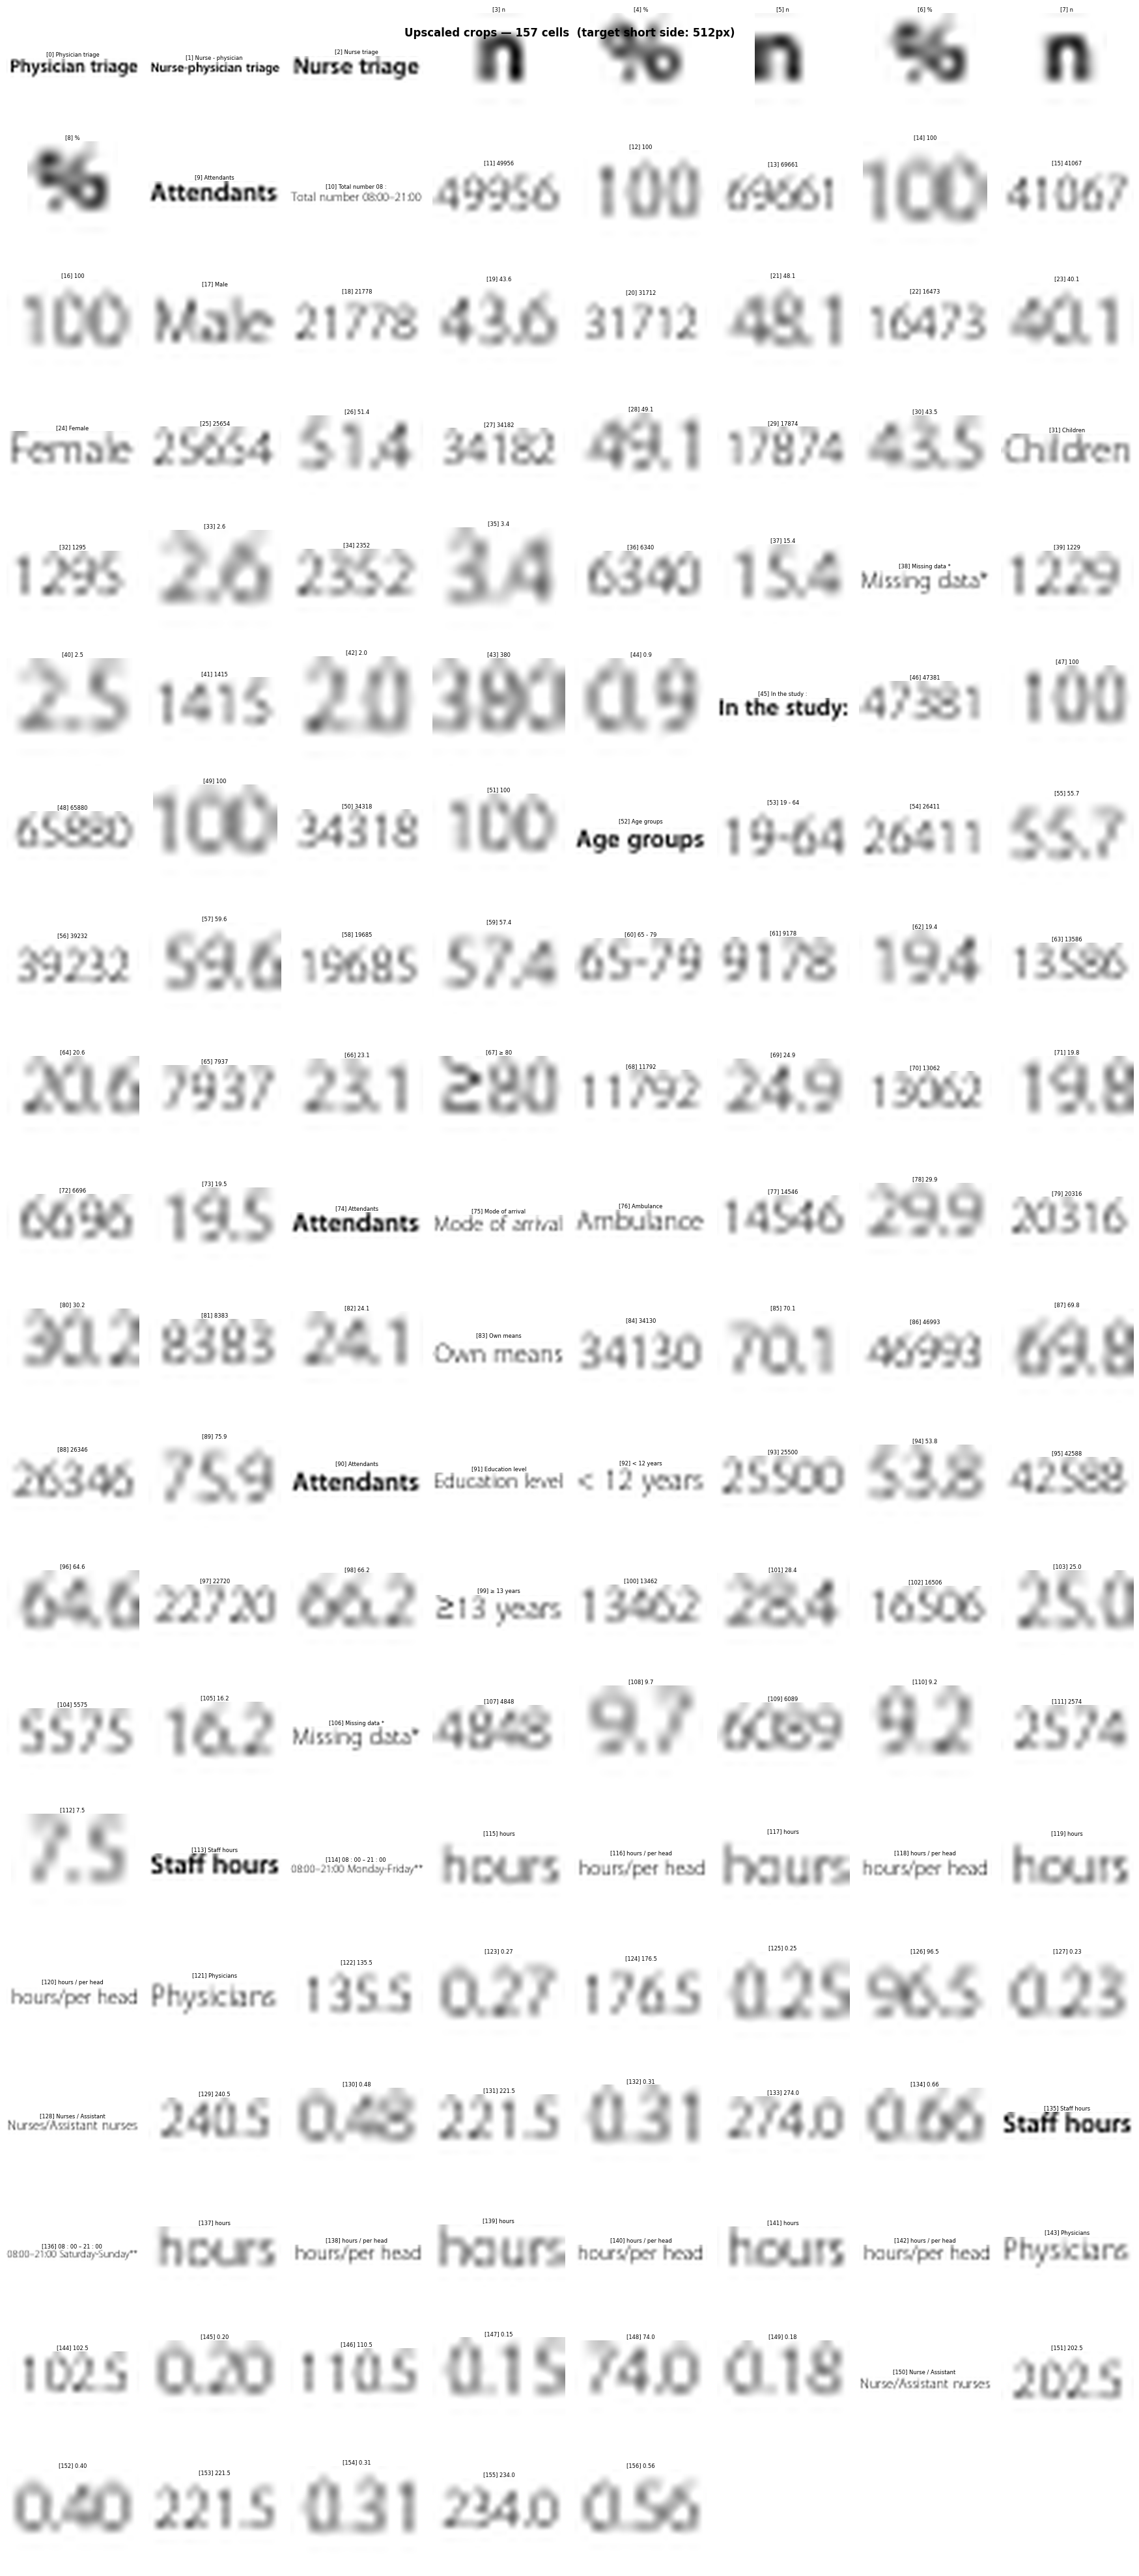

In [64]:
# ── Upscaled crops sent to Qwen (as the VLM sees them) ───────────────────────
_target = TARGET_SHORT_SIDE if 'TARGET_SHORT_SIDE' in dir() else 512

n    = len(cell_bboxes)
cols = 8
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.0))
axes = axes.flatten()

for i, (bbox, text) in enumerate(zip(cell_bboxes, cell_texts)):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    crop  = img.crop((x1, y1, x2, y2))
    w, h  = crop.size
    short = min(w, h)
    if short < _target:
        scale = _target / short
        crop  = crop.resize((round(w * scale), round(h * scale)), Image.LANCZOS)

    axes[i].imshow(crop)
    axes[i].set_title(f"[{i}] {text[:18]}", fontsize=6, pad=2)
    axes[i].axis("off")

    ow, oh = int(x2 - x1), int(y2 - y1)
    axes[i].set_xlabel(f"{ow}×{oh} → {crop.size[0]}×{crop.size[1]}",
                       fontsize=5, labelpad=1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Upscaled crops — {n} cells  (target short side: {_target}px)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [65]:
# ── Per-cell VLM correction via Qwen2.5-VL (OpenRouter) ──────────────────────
import copy, base64, io, time
from concurrent.futures import ThreadPoolExecutor
from openai import OpenAI

OPENROUTER_MODEL = "qwen/qwen2.5-vl-72b-instruct"

qwen_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY", ""),
)

CELL_PROMPT = (
    "You are correcting OCR output for a single table cell.\n"
    "The OCR model read this cell as: \"{text}\"\n\n"
    "Look at the zoomed-in cell image carefully.\n"
    "- If the text is correct, respond with EXACTLY: NO_CHANGES\n"
    "- If the text is wrong, respond with ONLY the corrected text — nothing else.\n\n"
    "UniTable is a strong model (avg TEDS ~0.95). Only correct if you are certain."
)

TARGET_SHORT_SIDE = 512  # px — upscale every crop so the short side is at least this

def _crop_to_b64(image, bbox):
    x1, y1, x2, y2 = [int(v) for v in bbox]
    crop = image.crop((x1, y1, x2, y2))
    w, h = crop.size
    short = min(w, h)
    if short < TARGET_SHORT_SIDE:
        scale = TARGET_SHORT_SIDE / short
        crop = crop.resize((round(w * scale), round(h * scale)), Image.LANCZOS)
    buf = io.BytesIO()
    crop.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def correct_cell(args):
    i, (bbox, text) = args
    b64 = _crop_to_b64(img, bbox)
    resp = qwen_client.chat.completions.create(
        model=OPENROUTER_MODEL,
        messages=[{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                {"type": "text",      "text": CELL_PROMPT.format(text=text)},
            ],
        }],
        max_tokens=64,
        temperature=0.0,
    )
    result = resp.choices[0].message.content.strip()
    corrected = text if result == "NO_CHANGES" else result
    return i, corrected, (result != "NO_CHANGES")

print(f"Correcting {len(cell_bboxes)} cells with {OPENROUTER_MODEL}...")
t0 = time.time()

corrected_texts = list(cell_texts)
changes = []

with ThreadPoolExecutor(max_workers=8) as pool:
    results = list(pool.map(correct_cell, enumerate(zip(cell_bboxes, cell_texts))))

for i, new_text, changed in results:
    corrected_texts[i] = new_text
    if changed:
        changes.append((i, cell_texts[i], new_text))

print(f"Done in {time.time() - t0:.1f}s")
print(f"Cells changed: {len(changes)}/{len(cell_bboxes)}")
for i, orig, new in changes:
    print(f"  [{i:2d}] '{orig}' → '{new}'")

Correcting 157 cells with qwen/qwen2.5-vl-72b-instruct...
Done in 78.5s
Cells changed: 1/157
  [ 0] 'Physician triage' → 'Physician image'


In [66]:
# ── Re-inject corrected texts into HTML structure ─────────────────────────────
from src.utils import build_table_from_html_and_cell, html_table_template

tokens_copy = copy.copy(structure_tokens)
pred_code = build_table_from_html_and_cell(tokens_copy, list(corrected_texts))
corrected_html = html_table_template("".join(pred_code))

print("=== ORIGINAL HTML ===")
print(raw_html)
print()
print("=== CORRECTED HTML ===")
print(corrected_html)


=== ORIGINAL HTML ===
<html>
        <head> <meta charset="UTF-8">
        <style>
        table, th, td {
            border: 1px solid black;
            font-size: 10px;
        }
        </style> </head>
        <body>
        <table frame="hsides" rules="groups" width="100%%">
            <thead><tr><td>Physician triage</td><td  colspan="2">Nurse - physician triage</td><td  colspan="2">Nurse triage</td><td  colspan="2">n</td></tr><tr><td>%</td><td>n</td><td>%</td><td>n</td><td>%</td><td>Attendants</td><td>Total number 08 : 00 – 21 : 00</td></tr></thead><tbody><tr><td>49956</td><td>100</td><td>69661</td><td>100</td><td>41067</td><td>100</td><td>Male</td></tr><tr><td>21778</td><td>43.6</td><td>31712</td><td>48.1</td><td>16473</td><td>40.1</td><td>Female</td></tr><tr><td>25654</td><td>51.4</td><td>34182</td><td>49.1</td><td>17874</td><td>43.5</td><td>Children</td></tr><tr><td>1295</td><td>2.6</td><td>2352</td><td>3.4</td><td>6340</td><td>15.4</td><td>Missing data *</td></tr><tr><td>1

In [67]:
# ── Side-by-side render ───────────────────────────────────────────────────────
style = """
<style>
  .compare { display: flex; gap: 40px; }
  .compare div { flex: 1; }
  table { border-collapse: collapse; font-size: 12px; width: 100%; }
  td, th { border: 1px solid #ccc; padding: 4px 8px; }
  th { background: #f0f0f0; }
  h4 { margin-bottom: 6px; }
</style>
"""
display(HTML(f"""{style}
<div class="compare">
  <div><h4>UniTable (original)</h4>{raw_html}</div>
  <div><h4>VLM-corrected</h4>{corrected_html}</div>
</div>
"""))

# Diff table
diff_rows = [{"idx": i, "original": cell_texts[i], "corrected": corrected_texts[i],
               "changed": cell_texts[i] != corrected_texts[i]}
             for i in range(len(cell_texts))]
df_diff = pd.DataFrame(diff_rows)
display(df_diff[df_diff["changed"]] if df_diff["changed"].any() else df_diff)


,idx,original,corrected,changed
0,0,Physician triage,Physician image,True


In [68]:
# ── Parsed structure analysis ─────────────────────────────────────────────────
soup = BeautifulSoup(raw_html or '', 'html.parser')
rows = soup.find_all('tr')
cells = soup.find_all(['td', 'th'])
headers = soup.find_all('th')

print(f'Rows:    {len(rows)}')
print(f'Cells:   {len(cells)}  ({len(headers)} <th>, {len(cells)-len(headers)} <td>)')

# Check for rowspan/colspan
spanning = [c for c in cells if c.get('rowspan') or c.get('colspan')]
print(f'Spanning cells (rowspan/colspan): {len(spanning)}')

# Cell text content
texts = [c.get_text(strip=True) for c in cells]
empty = sum(1 for t in texts if not t)
print(f'Empty cells: {empty}/{len(cells)}')

# Repeated text (hallucination indicator)
from collections import Counter
freq = Counter(t for t in texts if t)
repeated = {t: n for t, n in freq.items() if n > 2}
if repeated:
    print(f'\nRepeated cell text (hallucination risk):')
    for t, n in sorted(repeated.items(), key=lambda x: -x[1]):
        print(f'  "{t}" × {n}')
else:
    print('No repeated cell text detected')

Rows:    30
Cells:   157  (0 <th>, 157 <td>)
Spanning cells (rowspan/colspan): 3
Empty cells: 0/157

Repeated cell text (hallucination risk):
  "100" × 6
  "hours" × 6
  "hours / per head" × 6
  "n" × 3
  "%" × 3
  "Attendants" × 3


In [69]:
# ── Rendered table ────────────────────────────────────────────────────────────
styled = f"""
<style>
table {{ border-collapse: collapse; font-size: 12px; }}
td, th {{ border: 1px solid #ccc; padding: 4px 8px; }}
th {{ background: #f0f0f0; font-weight: bold; }}
</style>
{raw_html}
"""
display(HTML(styled))

In [70]:
# ── DataFrame view ────────────────────────────────────────────────────────────
try:
    dfs = pd.read_html(raw_html)
    print(f'{len(dfs)} table(s) parsed by pandas\n')
    for i, df in enumerate(dfs):
        print(f'Table {i}: {df.shape[0]} rows × {df.shape[1]} cols')
        display(df)
except Exception as e:
    print(f'pandas.read_html failed: {e}')

pandas.read_html failed: [Errno 2] No such file or directory: <html>
        <head> <meta charset="UTF-8">
        <style>
        table, th, td {
            border: 1px solid black;
            font-size: 10px;
        }
        </style> </head>
        <body>
        <table frame="hsides" rules="groups" width="100%%">
            <thead><tr><td>Physician triage</td><td  colspan="2">Nurse - physician triage</td><td  colspan="2">Nurse triage</td><td  colspan="2">n</td></tr><tr><td>%</td><td>n</td><td>%</td><td>n</td><td>%</td><td>Attendants</td><td>Total number 08 : 00 – 21 : 00</td></tr></thead><tbody><tr><td>49956</td><td>100</td><td>69661</td><td>100</td><td>41067</td><td>100</td><td>Male</td></tr><tr><td>21778</td><td>43.6</td><td>31712</td><td>48.1</td><td>16473</td><td>40.1</td><td>Female</td></tr><tr><td>25654</td><td>51.4</td><td>34182</td><td>49.1</td><td>17874</td><td>43.5</td><td>Children</td></tr><tr><td>1295</td><td>2.6</td><td>2352</td><td>3.4</td><td>6340</td><td>15.4</

In [71]:
# ── Compare UniTable-only vs Hybrid against ground truth ──────────────────────
stem = IMAGE_PATH.stem   # e.g. imgid_548924_TEDS0.911
gt_path = IMAGE_PATH.parent / f'{stem}_gt.html'

if gt_path.exists():
    gt_html = gt_path.read_text()

    teds       = TEDS(structure_only=False)
    teds_struct = TEDS(structure_only=True)

    wrap = lambda h: f'<html><body>{h}</body></html>'

    score_unitable_full   = teds.evaluate(wrap(raw_html), wrap(gt_html))
    score_unitable_struct = teds_struct.evaluate(wrap(raw_html), wrap(gt_html))

    score_hybrid_full     = teds.evaluate(wrap(corrected_html), wrap(gt_html))
    score_hybrid_struct   = teds_struct.evaluate(wrap(corrected_html), wrap(gt_html))

    filename_teds = float(stem.split('TEDS')[1])

    print(f"{'Pipeline':<20} {'TEDS (full)':>12} {'TEDS (struct)':>14}")
    print("-" * 48)
    print(f"{'UniTable only':<20} {score_unitable_full:>12.4f} {score_unitable_struct:>14.4f}")
    print(f"{'Hybrid (+ Qwen)':<20} {score_hybrid_full:>12.4f} {score_hybrid_struct:>14.4f}")
    print(f"{'Filename baseline':<20} {filename_teds:>12.3f}")
    print()

    delta_full   = score_hybrid_full   - score_unitable_full
    delta_struct = score_hybrid_struct - score_unitable_struct
    sign = lambda x: "+" if x >= 0 else ""
    print(f"Delta (hybrid − unitable):  full={sign(delta_full)}{delta_full:.4f}  struct={sign(delta_struct)}{delta_struct:.4f}")

    print('\n=== GROUND TRUTH HTML ===')
    print(gt_html)
else:
    print('No ground truth file found — skipping TEDS comparison')

Pipeline              TEDS (full)  TEDS (struct)
------------------------------------------------
UniTable only              0.2373         0.8054
Hybrid (+ Qwen)            0.2373         0.8054
Filename baseline           0.805

Delta (hybrid − unitable):  full=+0.0000  struct=+0.0000

=== GROUND TRUTH HTML ===
<html>
 <head>
  <meta charset="utf-8"/>
  <style>
   table, th, td {
                     border: 1px solid black;
                     font-size: 10px;
                   }
  </style>
 </head>
 <body>
  <table frame="hsides" rules="groups" width="100%">
   <thead>
    <tr>
     <td>
      <b>
      </b>
     </td>
     <td colspan="2">
      <b>
       Physician triage
      </b>
     </td>
     <td colspan="2">
      <b>
       Nurse-physician triage
      </b>
     </td>
     <td colspan="2">
      <b>
       Nurse triage
      </b>
     </td>
    </tr>
    <tr>
     <td>
      <b>
      </b>
     </td>
     <td>
      <b>
       n
      </b>
     </td>
     <td>
      <b>

In [72]:
# ── Cell-level value comparison: UniTable vs Hybrid vs Ground Truth ───────────
import io
from shared.eval import normalize_text, compare_tables, print_accuracy_summary

def html_to_df(html):
    """Parse first table in an HTML string into a DataFrame."""
    try:
        return pd.read_html(io.StringIO(html))[0]
    except Exception as e:
        print(f"  parse failed: {e}")
        return None

gt_path = IMAGE_PATH.parent / f'{IMAGE_PATH.stem}_gt.html'
if not gt_path.exists():
    print("No ground truth file — skipping value comparison")
else:
    gt_html_text = gt_path.read_text()

    df_gt      = html_to_df(gt_html_text)
    df_uni     = html_to_df(raw_html)
    df_hybrid  = html_to_df(corrected_html)

    if df_gt is None:
        print("Could not parse ground truth HTML")
    else:
        print(f"Ground truth:  {df_gt.shape[0]} rows × {df_gt.shape[1]} cols")
        if df_uni is not None:
            print(f"UniTable:      {df_uni.shape[0]} rows × {df_uni.shape[1]} cols")
        if df_hybrid is not None:
            print(f"Hybrid:        {df_hybrid.shape[0]} rows × {df_hybrid.shape[1]} cols")

        if df_uni is not None:
            print("\n" + "="*60)
            print("UNITABLE vs GROUND TRUTH")
            print("="*60)
            print_accuracy_summary(compare_tables(df_gt, df_uni))

        if df_hybrid is not None:
            print("\n" + "="*60)
            print("HYBRID (+ Qwen) vs GROUND TRUTH")
            print("="*60)
            print_accuracy_summary(compare_tables(df_gt, df_hybrid))

Ground truth:  28 rows × 7 cols
UniTable:      28 rows × 7 cols
Hybrid:        28 rows × 7 cols

UNITABLE vs GROUND TRUTH
ACCURACY SUMMARY
Ground truth rows:  28
Extracted rows:     28
Rows compared:      28
Missing rows:       0
Extra rows:         0

Total cells compared: 196
Correct cells:        7
Cell accuracy:        3.6%
Row match:            0.0%  (0/28 rows fully correct)

DETAILED MISMATCHES (189 cells)


,Row,Column,Ground Truth,Extracted
0,0,('unnamed: 0_level_0' 'unnamed: 0_level_1'),attendants,49956
1,1,('unnamed: 0_level_0' 'unnamed: 0_level_1'),total number 08:00-21:00,21778
2,2,('unnamed: 0_level_0' 'unnamed: 0_level_1'),male,25654
3,3,('unnamed: 0_level_0' 'unnamed: 0_level_1'),female,1295
4,4,('unnamed: 0_level_0' 'unnamed: 0_level_1'),children,1229
...,...,...,...,...
184,22,('nurse triage' '%'),023,
185,23,('nurse triage' '%'),066,
186,25,('nurse triage' '%'),hours/per head,
187,26,('nurse triage' '%'),018,



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,('unnamed: 0_level_0' 'unnamed: 0_level_1'),28,0,28,0.0%
1,('physician triage' 'n'),28,1,27,3.6%
2,('physician triage' '%'),28,1,27,3.6%
3,('nurse-physician triage' 'n'),28,1,27,3.6%
4,('nurse-physician triage' '%'),28,1,27,3.6%
5,('nurse triage' 'n'),28,1,27,3.6%
6,('nurse triage' '%'),28,2,26,7.1%



HYBRID (+ Qwen) vs GROUND TRUTH
ACCURACY SUMMARY
Ground truth rows:  28
Extracted rows:     28
Rows compared:      28
Missing rows:       0
Extra rows:         0

Total cells compared: 196
Correct cells:        7
Cell accuracy:        3.6%
Row match:            0.0%  (0/28 rows fully correct)

DETAILED MISMATCHES (189 cells)


,Row,Column,Ground Truth,Extracted
0,0,('unnamed: 0_level_0' 'unnamed: 0_level_1'),attendants,49956
1,1,('unnamed: 0_level_0' 'unnamed: 0_level_1'),total number 08:00-21:00,21778
2,2,('unnamed: 0_level_0' 'unnamed: 0_level_1'),male,25654
3,3,('unnamed: 0_level_0' 'unnamed: 0_level_1'),female,1295
4,4,('unnamed: 0_level_0' 'unnamed: 0_level_1'),children,1229
...,...,...,...,...
184,22,('nurse triage' '%'),023,
185,23,('nurse triage' '%'),066,
186,25,('nurse triage' '%'),hours/per head,
187,26,('nurse triage' '%'),018,



PER-COLUMN ACCURACY


,Column,Total Cells,Correct,Errors,Accuracy
0,('unnamed: 0_level_0' 'unnamed: 0_level_1'),28,0,28,0.0%
1,('physician triage' 'n'),28,1,27,3.6%
2,('physician triage' '%'),28,1,27,3.6%
3,('nurse-physician triage' 'n'),28,1,27,3.6%
4,('nurse-physician triage' '%'),28,1,27,3.6%
5,('nurse triage' 'n'),28,1,27,3.6%
6,('nurse triage' '%'),28,2,26,7.1%


---
## Batch Eval — UniTable vs Hybrid (20 images)

In [33]:
# ── Batch eval: UniTable-only vs Hybrid on 20 images ─────────────────────────
import random
from src.utils import build_table_from_html_and_cell, html_table_template

BATCH_N    = 20
BATCH_SEED = 42

teds_full   = TEDS(structure_only=False)
teds_struct = TEDS(structure_only=True)
wrap = lambda h: f'<html><body>{h}</body></html>'

images_with_gt = [p for p in sorted(EVAL_DIR.glob('*.png'))
                  if (EVAL_DIR / f'{p.stem}_gt.html').exists()]
print(f"Images with ground truth: {len(images_with_gt)}")

random.seed(BATCH_SEED)
batch = random.sample(images_with_gt, min(BATCH_N, len(images_with_gt)))
print(f"Running batch of {len(batch)} images...\n")

def run_hybrid_on_image(image_path):
    im = Image.open(image_path)
    r_html, bboxes, texts, tokens = extractor.extract_html_with_bboxes(im)

    corrected = list(texts)
    def _correct(args):
        i, (bbox, text) = args
        b64 = _crop_to_b64(im, bbox)
        resp = qwen_client.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[{"role": "user", "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                {"type": "text", "text": CELL_PROMPT.format(text=text)},
            ]}],
            max_tokens=64,
            temperature=0.0,
        )
        result = resp.choices[0].message.content.strip()
        return i, (text if result == "NO_CHANGES" else result)

    with ThreadPoolExecutor(max_workers=8) as pool:
        for i, new_text in pool.map(_correct, enumerate(zip(bboxes, texts))):
            corrected[i] = new_text

    tokens_copy = list(tokens)
    pred_code   = build_table_from_html_and_cell(tokens_copy, corrected)
    c_html      = html_table_template("".join(pred_code))
    return r_html, c_html

results = []
for idx, img_path in enumerate(batch):
    stem    = img_path.stem
    gt_html = (EVAL_DIR / f'{stem}_gt.html').read_text()

    t0 = time.time()
    try:
        raw, corrected = run_hybrid_on_image(img_path)
        elapsed = time.time() - t0

        uni  = teds_full.evaluate(wrap(raw),       wrap(gt_html))
        hyb  = teds_full.evaluate(wrap(corrected), wrap(gt_html))
        delta   = hyb - uni
        outcome = "improved" if delta > 0.01 else ("regressed" if delta < -0.01 else "same")

        results.append({"image": stem, "unitable": uni, "hybrid": hyb,
                         "delta": delta, "outcome": outcome, "time_s": elapsed})
        print(f"[{idx+1:2d}/{len(batch)}] {stem[-32:]:32s}  uni={uni:.3f}  hyb={hyb:.3f}  Δ={delta:+.3f}  ({outcome})  {elapsed:.0f}s")
    except Exception as e:
        print(f"[{idx+1:2d}/{len(batch)}] {stem[-32:]:32s}  ERROR: {e}")
        results.append({"image": stem, "unitable": None, "hybrid": None,
                         "delta": None, "outcome": "error", "time_s": None})

# ── Summary ───────────────────────────────────────────────────────────────────
df_batch = pd.DataFrame(results)
valid    = df_batch[df_batch["outcome"] != "error"]

print(f"\n{'='*55}")
print(f"{'Metric':<30} {'Value':>10}")
print(f"{'-'*40}")
print(f"{'Mean TEDS — UniTable':<30} {valid['unitable'].mean():>10.4f}")
print(f"{'Mean TEDS — Hybrid':<30} {valid['hybrid'].mean():>10.4f}")
print(f"{'Mean delta':<30} {valid['delta'].mean():>+10.4f}")
print(f"{'Improved  (Δ > +0.01)':<30} {(valid['outcome']=='improved').sum():>10}")
print(f"{'Same      (|Δ| ≤ 0.01)':<30} {(valid['outcome']=='same').sum():>10}")
print(f"{'Regressed (Δ < -0.01)':<30} {(valid['outcome']=='regressed').sum():>10}")
print(f"{'Errors':<30} {(df_batch['outcome']=='error').sum():>10}")
print(f"{'='*55}")

display(df_batch.sort_values("delta"))

Images with ground truth: 500
Running batch of 20 images...

[ 1/20] imgid_671062_TEDS0.925            uni=0.333  hyb=0.333  Δ=+0.000  (same)  37s
[ 2/20] imgid_567147_TEDS0.822            uni=0.324  hyb=0.323  Δ=-0.001  (same)  90s
[ 3/20] imgid_553039_TEDS0.789            uni=0.261  hyb=0.261  Δ=+0.000  (same)  68s
[ 4/20] imgid_690729_TEDS0.887            uni=0.317  hyb=0.316  Δ=-0.001  (same)  82s
[ 5/20] imgid_594972_TEDS0.729            uni=0.331  hyb=0.331  Δ=+0.000  (same)  25s
[ 6/20] imgid_587963_TEDS0.927            uni=0.342  hyb=0.342  Δ=+0.000  (same)  34s
[ 7/20] imgid_586111_TEDS0.922            uni=0.284  hyb=0.284  Δ=+0.000  (same)  58s
[ 8/20] imgid_570348_TEDS0.892            uni=0.322  hyb=0.322  Δ=+0.000  (same)  315s
[ 9/20] imgid_689455_TEDS0.721            uni=0.408  hyb=0.408  Δ=+0.000  (same)  625s
[10/20] imgid_564918_TEDS0.929            uni=0.380  hyb=0.380  Δ=+0.000  (same)  48s
[11/20] imgid_676926_TEDS0.826            ERROR: Expecting value: line 13 col

,image,unitable,hybrid,delta,outcome,time_s
1,imgid_567147_TEDS0.822,0.324193,0.323142,-0.001051,same,89.940789
3,imgid_690729_TEDS0.887,0.316829,0.316204,-0.000625,same,81.909497
12,imgid_652352_TEDS0.841,0.456212,0.455950,-0.000262,same,105.946883
0,imgid_671062_TEDS0.925,0.333266,0.333266,0.000000,same,36.916694
2,imgid_553039_TEDS0.789,0.260580,0.260580,0.000000,same,68.402685
4,imgid_594972_TEDS0.729,0.331187,0.331187,0.000000,same,25.496086
5,imgid_587963_TEDS0.927,0.342045,0.342045,0.000000,same,34.101154
6,imgid_586111_TEDS0.922,0.284024,0.284024,0.000000,same,58.250792
7,imgid_570348_TEDS0.892,0.321951,0.321951,0.000000,same,314.830333
8,imgid_689455_TEDS0.721,0.408449,0.408449,0.000000,same,624.810513
